### Predict Heart Disease using Logistic Regression

#### Import Libraries 

In [2]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [4]:
df = pd.read_csv(r"C:\Users\epist\Documents\PYTHON TUTORIALS\Portfolio collection\Heart disease\heart.csv")

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [7]:
df.shape

(303, 14)

### Step 1: Explore the Dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
298    False
299    False
300    False
301    False
302    False
Length: 303, dtype: bool

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.shape

(302, 14)

### Step 2: Exploratory Data Analysis

In [13]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [14]:
# Patients affected(1) and not affected(0) by heart disease

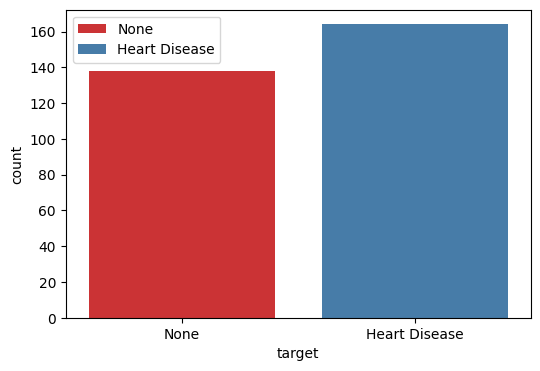

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='target', hue='target', palette='Set1')
plt.xticks([0,1], ['None', 'Heart Disease'])
plt.legend(labels=['None', 'Heart Disease'])
                            
plt.show();

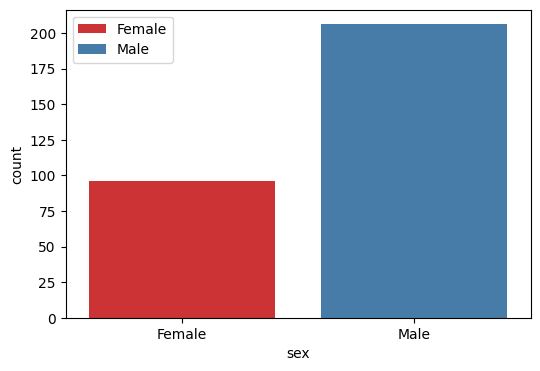

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex', hue='sex', palette='Set1')
plt.xticks([0,1], ['Female', 'Male'])
plt.legend(labels=['Female', 'Male'])

plt.show();

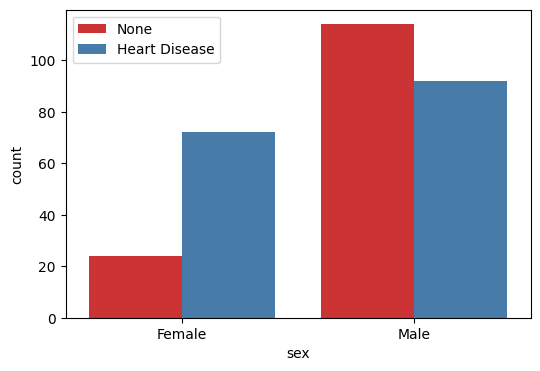

In [17]:
#Distribution of Gender based on heart disease
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex', hue='target', palette='Set1')
plt.xticks([0,1], ['Female', 'Male'])
plt.legend(labels=['None', 'Heart Disease'])

plt.show();

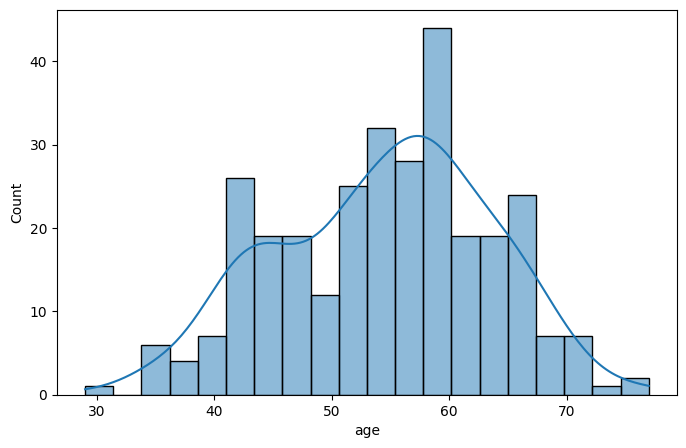

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', bins=20, kde=True)

plt.show();

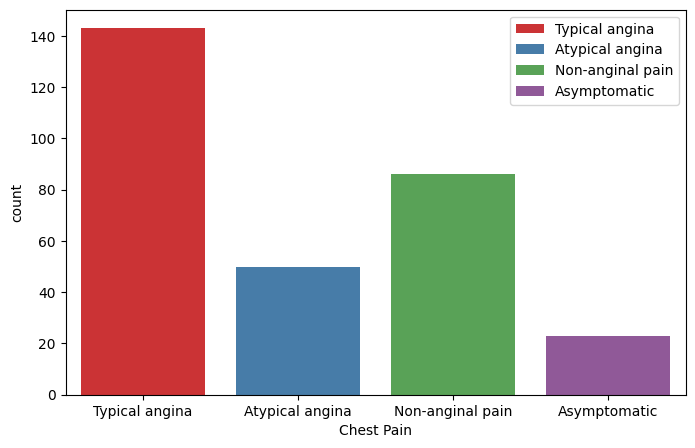

In [19]:
# Chest pain type
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='cp', hue='cp', palette='Set1')
plt.xticks([0,1,2,3], ['Typical angina', 'Atypical angina', 'Non-anginal pain', 'Asymptomatic'])
plt.legend(labels=['Typical angina', 'Atypical angina', 'Non-anginal pain', 'Asymptomatic'])
plt.xlabel('Chest Pain')

plt.show();

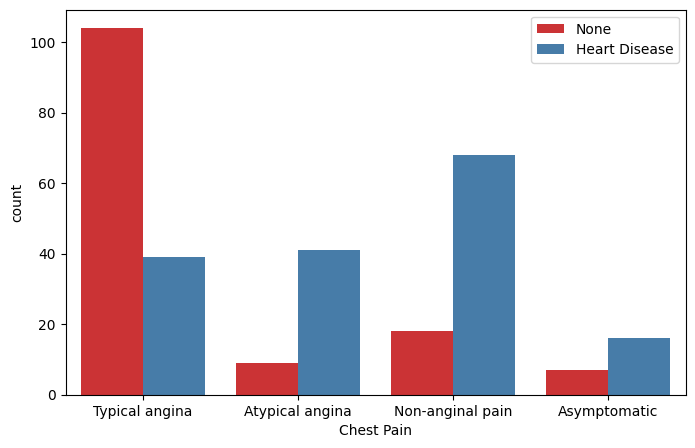

In [20]:
# Chest pain distribution based on heart disease or no heart disease
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='cp', hue='target', palette='Set1')
plt.xticks([0,1,2,3], ['Typical angina', 'Atypical angina', 'Non-anginal pain', 'Asymptomatic'])
plt.legend(labels=['None', 'Heart Disease'])
plt.xlabel('Chest Pain')

plt.show();

In [21]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


In [22]:
# Visualize the correlation

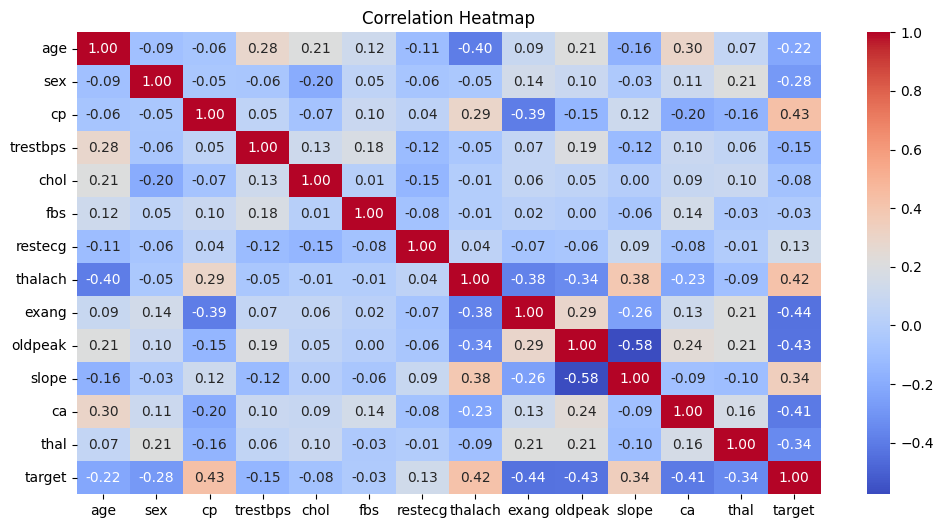

In [23]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

#### Most positively Correlated Features

In [24]:
corr_matrix = df.corr()

target = 'target'

corr_with_target = corr_matrix[target].sort_values(ascending=False)

print("Most Positively Correlated Features:")
print(corr_with_target.head(6))

Most Positively Correlated Features:
target     1.000000
cp         0.432080
thalach    0.419955
slope      0.343940
restecg    0.134874
fbs       -0.026826
Name: target, dtype: float64


#### Most positively Correlated Features

In [25]:
corr_matrix = df.corr()

target = 'target'

corr_with_target = corr_matrix[target].sort_values(ascending=False)

print("Most Positively Correlated Features:")
print(corr_with_target.tail(5))

Most Positively Correlated Features:
sex       -0.283609
thal      -0.343101
ca        -0.408992
oldpeak   -0.429146
exang     -0.435601
Name: target, dtype: float64


### Step 3: Prepare the Data

In [26]:
# Split features and target
X = df[["cp","thalach","slope","restecg","fbs","sex","thal","ca","exang","oldpeak"]]
y = df["target"]

In [27]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 4: Train the model

In [29]:
# Train logistic regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

### Step 5: Evaluate the model

In [30]:
# Predict
y_pred = model.predict(X_test_scaled)

In [31]:
# Evaluate
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

In [32]:
print("Accuracy:", accuracy)
print("\nClassification Report:\n", report)

Accuracy: 0.8688524590163934

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



### Step 6: Save the model

In [33]:
joblib.dump(model, 'heart_model.joblib')

['heart_model.joblib']

### Done! Built a working heart disease prediction

C:\Users\epist\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


NameError: name 'pipe' is not defined

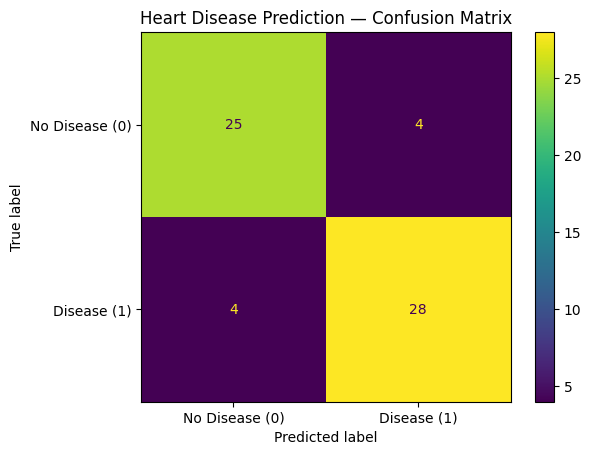

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# If you already have y_pred:
# y_pred = model.predict(X_test)  # or pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease (0)", "Disease (1)"]
)
disp.plot(values_format="d")
plt.title("Heart Disease Prediction — Confusion Matrix")
plt.show()

C:\Users\epist\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


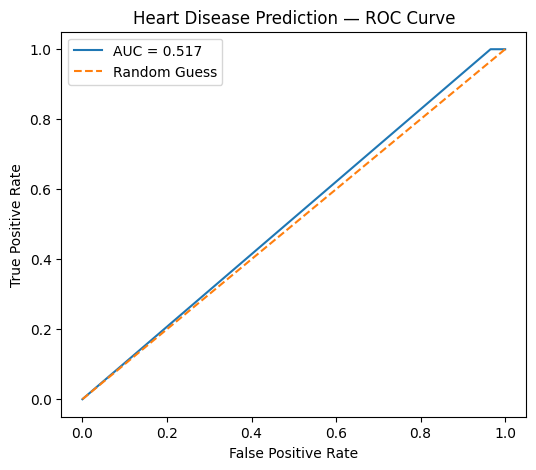

ROC-AUC: 0.5172413793103448


In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilities for class 1 (Disease)
# If using a plain model:
y_prob = model.predict_proba(X_test)[:, 1]

# If using a pipeline (pipe) instead:
# y_prob = pipe.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], "--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Heart Disease Prediction — ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC:", auc_score)

C:\Users\epist\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


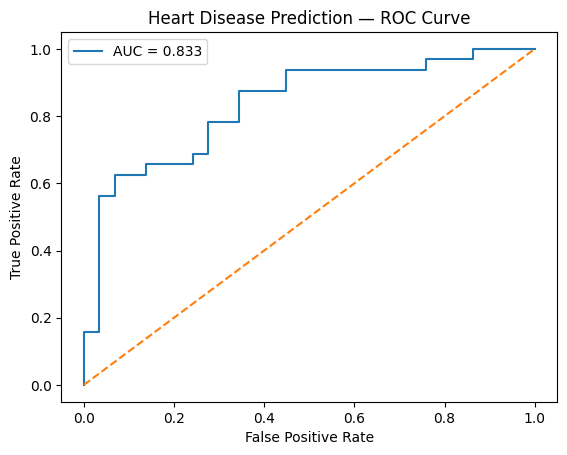

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score

y_score = model.decision_function(X_test)  # or pipe.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score)
auc_score = roc_auc_score(y_test, y_score)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Heart Disease Prediction — ROC Curve")
plt.legend()
plt.show()